In [ ]:
#Author: Maciej Brzozowski

In [315]:
import numpy as np
import math
import matplotlib.pyplot as plt
from uncertainties import ufloat
from uncertainties.umath import sqrt
g=981 #cm/s^2

In [316]:
metr_error=0.1
suwmiarka_error=0.02
mass_error=0.1
time_error=0.4 #on and off

def error(data, instrument_error):
    if len(data)==1:
        return instrument_error
    stat_error = np.std(data, ddof=1) / np.sqrt(len(data))
    return np.sqrt(stat_error**2+(instrument_error)**2)

def process(data,instrument_error):
    return ufloat(np.mean(data),error(data,instrument_error))

def printer(*args):
    print(*('{:.2u}'.format(x) for x in args))
    print(*('{:.2uL}'.format(x) for x in args))

In [317]:
m_pL = process([794.5],mass_error) #g
m_pR = process([793.5],mass_error) #g
m_kL = process([1039.0],mass_error) #g
m_kR = process([1039.2],mass_error) #g
printer(m_kR)

1039.20+/-0.10
1039.20 \pm 0.10


In [318]:
h_pL_measure = [118.1,118.1,118.1] #cm
h_pR_measure = [118.1,118.2,118.2] #cm
h_pL = process(h_pL_measure,metr_error) #cm
h_pR = process(h_pR_measure,metr_error) #cm
printer(h_pL)
printer(h_pR)

118.10+/-0.10
118.10 \pm 0.10
118.17+/-0.11
118.17 \pm 0.11


In [319]:
h_kL_measure = [1.92,1.86,1.94] #cm
h_kR_measure = [1.94,1.92,1.92] #cm
h_kL = process(h_kL_measure,suwmiarka_error) #cm
h_kR = process(h_kR_measure,suwmiarka_error) #cm
printer(h_kL)
printer(h_kR)

1.907+/-0.031
1.907 \pm 0.031
1.927+/-0.021
1.927 \pm 0.021


In [320]:
s = [49.1,25.8,76.9]

In [321]:
diameter_L_meansure = [8.92,8.90,8.86] #cm
diameter_R_meansure = [8.72,8.74,8.70] #cm
diameter_L = process(diameter_L_meansure,suwmiarka_error) #cm
diameter_R = process(diameter_R_meansure,suwmiarka_error) #cm
printer(diameter_L)
printer(diameter_R)
r_L = diameter_L/2
r_R = diameter_R/2
printer(r_L,r_R)

8.893+/-0.027
8.893 \pm 0.027
8.720+/-0.023
8.720 \pm 0.023
4.447+/-0.013 4.360+/-0.012
4.447 \pm 0.013 4.360 \pm 0.012


In [322]:
#odleglosc od punktu zaczepienia do początku krążka 
d_L = ufloat(98.6,metr_error) #cm 
d_R = ufloat(98.6,metr_error) #cm

In [323]:
#odleglosc od punktu zaczepienia do środka ciezkosci wahadla 
l_L = ((h_pL/2)*m_pL + (d_L + h_kL/2)*m_kL)/(m_pL + m_kL) #cm
l_R = ((h_pR/2)*m_pR + (d_R + h_kR/2)*m_kR)/(m_pR + m_kR) #cm
printer(l_L)
printer(l_R)

82.002+/-0.061
82.002 \pm 0.061
82.037+/-0.061
82.037 \pm 0.061


In [324]:
T_0_10_L_measure = [19.40,19.28,19.35,19.43,19.21]
T_0_10_R_measure = [19.31,19.41,19.32,19.32,19.35]
T_0_10_L = process(T_0_10_L_measure,time_error)
T_0_10_R = process(T_0_10_R_measure,time_error)
printer(T_0_10_L,T_0_10_R)
T_0_L = T_0_10_L/10
T_0_R = T_0_10_R/10
printer(T_0_L,T_0_R)

19.33+/-0.40 19.34+/-0.40
19.33 \pm 0.40 19.34 \pm 0.40
1.933+/-0.040 1.934+/-0.040
1.933 \pm 0.040 1.934 \pm 0.040


In [325]:
T_1_10_s1_measure = [19.12,19.25,19.13]
T_2_10_s1_measure = [16.19,16.13,16.15]
T_d_10_s1_measure = [106.44,107.19,106.72]

T_1_10_s1 = process(T_1_10_s1_measure,time_error) 
T_2_10_s1 = process(T_2_10_s1_measure,time_error)
T_d_10_s1 = process(T_d_10_s1_measure,time_error)


T_1_s1 = T_1_10_s1/10
T_2_s1 = T_2_10_s1/10
T_d_s1 = T_d_10_s1/10

printer(T_1_10_s1,T_2_10_s1,T_d_10_s1)
printer(T_1_s1,T_2_s1,T_d_s1)

19.17+/-0.40 16.16+/-0.40 106.78+/-0.46
19.17 \pm 0.40 16.16 \pm 0.40 106.78 \pm 0.46
1.917+/-0.040 1.616+/-0.040 10.678+/-0.046
1.917 \pm 0.040 1.616 \pm 0.040 10.678 \pm 0.046


In [326]:
T_1_10_s2_measure = [19.32,19.34,19.40]
T_2_10_s2_measure = [13.56,13.60,13.60]
T_d_10_s2_measure = [47.03,47.03,46.97]

T_1_10_s2 = process(T_1_10_s2_measure,time_error) 
T_2_10_s2 = process(T_2_10_s2_measure,time_error)
T_d_10_s2 = process(T_d_10_s2_measure,time_error)


T_1_s2 = T_1_10_s2/10
T_2_s2 = T_2_10_s2/10
T_d_s2 = T_d_10_s2/10

printer(T_1_10_s2,T_2_10_s2,T_d_10_s2)
printer(T_1_s2,T_2_s2,T_d_s2)

19.35+/-0.40 13.59+/-0.40 47.01+/-0.40
19.35 \pm 0.40 13.59 \pm 0.40 47.01 \pm 0.40
1.935+/-0.040 1.359+/-0.040 4.701+/-0.040
1.935 \pm 0.040 1.359 \pm 0.040 4.701 \pm 0.040


In [327]:
T_1_10_s3_measure = [19.28,19.34,19.13]
T_2_10_s3_measure = [18.41,18.47,18.53]
T_d_4_s3_measure = [184.59,183.75,184.37]

T_1_10_s3 = process(T_1_10_s3_measure,time_error) 
T_2_10_s3 = process(T_2_10_s3_measure,time_error)
T_d_4_s3 = process(T_d_4_s3_measure,time_error)


T_1_s3 = T_1_10_s3/10
T_2_s3 = T_2_10_s3/10
T_d_s3 = T_d_4_s3/4

printer(T_1_10_s3,T_2_10_s3,T_d_4_s3)
printer(T_1_s3,T_2_s3,T_d_s3)

19.25+/-0.40 18.47+/-0.40 184.24+/-0.47
19.25 \pm 0.40 18.47 \pm 0.40 184.24 \pm 0.47
1.925+/-0.040 1.847+/-0.040 46.06+/-0.12
1.925 \pm 0.040 1.847 \pm 0.040 46.06 \pm 0.12


In [328]:
I_pL = 1/3*m_pL*(h_pL**2)
I_pR = 1/3*m_pR*(h_pR**2)

I_kL_0 = 1/12*m_kL*(3*(r_L**2)+(h_kL**2))
I_kR_0 = 1/12*m_kR*(3*(r_R**2)+(h_kR**2))

#Steiner
I_kL = I_kL_0 + m_kL*((d_L+h_kL/2)**2)
I_kR = I_kR_0 + m_kR*((d_R+h_kR/2)**2)

I_L = I_pL+I_kL
I_R = I_pR+I_kR

printer(I_L,I_R)

(1.3997+/-0.0022)e+07 (1.4000+/-0.0022)e+07
\left(1.3997 \pm 0.0022\right) \times 10^{7} \left(1.4000 \pm 0.0022\right) \times 10^{7}


In [329]:
omega_0_L = 2*math.pi/T_0_L
omega_0_R = 2*math.pi/T_0_R

printer(omega_0_L,omega_0_R)

3.250+/-0.068 3.248+/-0.067
3.250 \pm 0.068 3.248 \pm 0.067


In [330]:
m_L = m_kL+m_pL
m_R = m_kR+m_pR
D_L = m_L*g*l_L
D_R = m_R*g*l_R
printer(D_L,D_R)

(1.4749+/-0.0011)e+08 (1.4749+/-0.0011)e+08
\left(1.4749 \pm 0.0011\right) \times 10^{8} \left(1.4749 \pm 0.0011\right) \times 10^{8}


In [331]:
omega_0_L_theory = sqrt(D_L/I_L)
omega_0_R_theory = sqrt(D_R/I_R)

printer(omega_0_L_theory,omega_0_R_theory)

3.2462+/-0.0013 3.2458+/-0.0013
3.2462 \pm 0.0013 3.2458 \pm 0.0013


In [332]:
T_d_s1_theory = (T_0_L*T_2_s1)/(T_0_L-T_2_s1)
printer(T_d_s1_theory,T_d_s1)

9.8+/-1.8 10.678+/-0.046
9.8 \pm 1.8 10.678 \pm 0.046


In [333]:
T_d_s2_theory = (T_0_L*T_2_s2)/(T_0_L-T_2_s2)
printer(T_d_s2_theory,T_d_s2)

4.57+/-0.51 4.701+/-0.040
4.57 \pm 0.51 4.701 \pm 0.040


In [334]:
T_d_s3_theory = (T_0_L*T_2_s3)/(T_0_L-T_2_s3)
printer(T_d_s3_theory,T_d_s3)

41+/-27 46.06+/-0.12
41 \pm 27 46.06 \pm 0.12


In [335]:
D_s_s1 = 4*(math.pi**2)*I_L/(T_0_L*T_d_s1)
D_s_s2 = 4*(math.pi**2)*I_L/(T_0_L*T_d_s2)
D_s_s3 = 4*(math.pi**2)*I_L/(T_0_L*T_d_s3)
printer(D_s_s1,D_s_s2,D_s_s3)

(2.676+/-0.057)e+07 (6.08+/-0.14)e+07 (6.21+/-0.13)e+06
\left(2.676 \pm 0.057\right) \times 10^{7} \left(6.08 \pm 0.14\right) \times 10^{7} \left(6.21 \pm 0.13\right) \times 10^{6}


In [336]:
D =[D_s_s1.n,D_s_s2.n,D_s_s3.n]
D_err = [D_s_s1.s,D_s_s2.s,D_s_s3.s]
a,b,c = np.polyfit(s, D, deg=2)
x_fit = np.linspace(min(s), max(s), 100)
y_fit = a * x_fit**2 + b * x_fit + c

print(a,b,c)

14109.86050234197 -2517388.610843431 116352025.28023073


Text(0.5, 1.0, 'Zależność momentu sprzęgającego od odległości krążka od punktu zaczepienia')

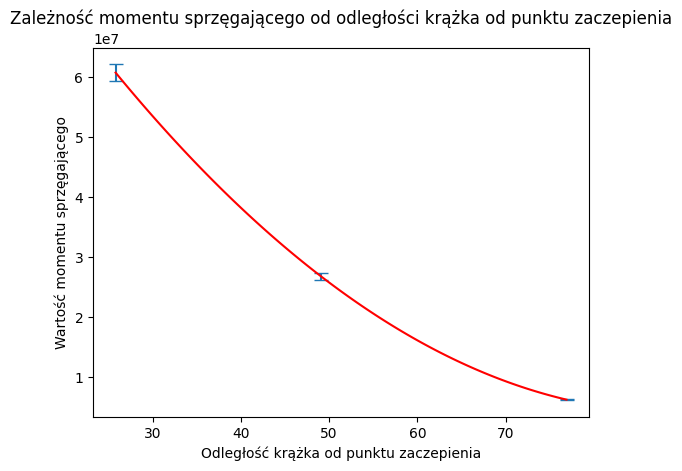

In [337]:
plt.errorbar(s, D,D_err,fmt='none',capsize=5)
plt.plot(x_fit, y_fit, 'r-')
plt.xlabel("Odległość krążka od punktu zaczepienia")
plt.ylabel("Wartość momentu sprzęgającego")
plt.title("Zależność momentu sprzęgającego od odległości krążka od punktu zaczepienia")

In [340]:
omega_2_s1 = 2*math.pi/T_2_s1
omega_2_s2 = 2*math.pi/T_2_s2
omega_2_s3 = 2*math.pi/T_2_s3
K_s1 = (omega_2_s1**2 - omega_0_L**2)/2 
K_s2 = (omega_2_s2**2 - omega_0_L**2)/2 
K_s3 = (omega_2_s3**2 - omega_0_L**2)/2

printer(K_s1,K_s2,K_s3)


D_s_s1_v2 = K_s1*I_L
D_s_s2_v2 = K_s2*I_L
D_s_s3_v2 = K_s3*I_L
printer(D_s_s1_v2,D_s_s2_v2,D_s_s3_v2)



2.28+/-0.43 5.41+/-0.67 0.51+/-0.33
2.28 \pm 0.43 5.41 \pm 0.67 0.51 \pm 0.33
(3.19+/-0.61)e+07 (7.58+/-0.93)e+07 (7.1+/-4.7)e+06
\left(3.19 \pm 0.61\right) \times 10^{7} \left(7.58 \pm 0.93\right) \times 10^{7} \left(7.1 \pm 4.7\right) \times 10^{6}
